# Practical Statistics for Data Scientists
## Chapter 1 — Exploratory Data Analysis

**Code Reproduction + Theoretical Deep-Dive**

Notebook ini merupakan implementasi orisinal Chapter 1 berdasarkan struktur materi *Practical Statistics for Data Scientists* (2nd Edition).

### Tujuan Pembelajaran
Chapter ini membangun fondasi analisis data sebelum masuk ke pemodelan Machine Learning maupun Deep Learning. Fokusnya adalah memahami struktur data, ukuran pemusatan, ukuran variasi, distribusi, data kategorikal, korelasi, dan hubungan antarvariabel.

Kode ditulis ulang dan diperluas dengan visualisasi serta interpretasi agar setiap hasil dapat dijelaskan secara akademik.

## 1. Import Library dan Konfigurasi

Bagian ini menyiapkan library untuk manipulasi data, komputasi statistik, dan visualisasi. Dataset `state.csv` digunakan sebagai dataset utama karena menjadi contoh inti pada Chapter 1.

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import trim_mean
from statsmodels import robust

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

STATE_CSV = '''State,Population,Murder.Rate,Abbreviation
Alabama,4779736,5.7,AL
Alaska,710231,5.6,AK
Arizona,6392017,4.7,AZ
Arkansas,2915918,5.6,AR
California,37253956,4.4,CA
Colorado,5029196,2.8,CO
Connecticut,3574097,2.4,CT
Delaware,897934,5.8,DE
Florida,18801310,5.8,FL
Georgia,9687653,5.7,GA
Hawaii,1360301,1.8,HI
Idaho,1567582,2.0,ID
Illinois,12830632,5.3,IL
Indiana,6483802,5.0,IN
Iowa,3046355,1.9,IA
Kansas,2853118,3.1,KS
Kentucky,4339367,3.6,KY
Louisiana,4533372,10.3,LA
Maine,1328361,1.6,ME
Maryland,5773552,6.1,MD
Massachusetts,6547629,2.0,MA
Michigan,9883640,5.4,MI
Minnesota,5303925,1.6,MN
Mississippi,2967297,8.6,MS
Missouri,5988927,6.6,MO
Montana,989415,3.6,MT
Nebraska,1826341,2.9,NE
Nevada,2700551,6.0,NV
New Hampshire,1316470,0.9,NH
New Jersey,8791894,3.9,NJ
New Mexico,2059179,4.8,NM
New York,19378102,3.1,NY
North Carolina,9535483,5.1,NC
North Dakota,672591,3.0,ND
Ohio,11536504,4.0,OH
Oklahoma,3751351,4.5,OK
Oregon,3831074,2.0,OR
Pennsylvania,12702379,4.8,PA
Rhode Island,1052567,2.4,RI
South Carolina,4625364,6.4,SC
South Dakota,814180,2.3,SD
Tennessee,6346105,5.7,TN
Texas,25145561,4.4,TX
Utah,2763885,2.3,UT
Vermont,625741,1.6,VT
Virginia,8001024,4.1,VA
Washington,6724540,2.5,WA
West Virginia,1852994,4.0,WV
Wisconsin,5686986,2.9,WI
Wyoming,563626,2.7,WY
'''
AIRLINE_CSV = '''Cause,Delay_Minutes
Carrier,64263.16
ATC,84856.50
Weather,11235.42
Security,343.15
Inbound,118427.82
'''

state = pd.read_csv(io.StringIO(STATE_CSV))
dfw = pd.read_csv(io.StringIO(AIRLINE_CSV))

## 2. Elements of Structured Data

Data terstruktur dapat direpresentasikan sebagai observasi dan atribut. Pada dataset `state`, satu baris merepresentasikan satu negara bagian, sedangkan kolom menggambarkan atribut seperti populasi dan murder rate.

Memahami unit observasi dan tipe variabel merupakan langkah awal agar statistik yang digunakan sesuai.

In [2]:
print("Ukuran dataset:", state.shape)
print("\nNama kolom:")
print(state.columns.tolist())

print("\nTipe data:")
print(state.dtypes)

print("\nLima observasi pertama:")
display(state.head())

Ukuran dataset: (50, 4)

Nama kolom:
['State', 'Population', 'Murder.Rate', 'Abbreviation']

Tipe data:
State            object
Population        int64
Murder.Rate     float64
Abbreviation     object
dtype: object

Lima observasi pertama:


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.700,AL
1,Alaska,710231,5.600,AK
2,Arizona,6392017,4.700,AZ
3,Arkansas,2915918,5.600,AR
4,California,37253956,4.400,CA


**Interpretasi:** Dataset berbentuk rectangular dengan satu observasi per negara bagian. `Population` dan `Murder.Rate` merupakan variabel numerik, sedangkan `State` dan `Abbreviation` berfungsi sebagai informasi kategorikal/identifier.

## 3. Rectangular Data

Data rectangular memiliki baris sebagai observasi dan kolom sebagai variabel. Sebelum menghitung statistik, dilakukan pemeriksaan dimensi, missing value, serta statistik deskriptif.

In [3]:
print("Jumlah baris:", len(state))
print("Jumlah kolom:", state.shape[1])

print("\nMissing values:")
display(state.isna().sum().to_frame("Missing"))

print("\nStatistik deskriptif:")
display(state[["Population", "Murder.Rate"]].describe().T)

Jumlah baris: 50
Jumlah kolom: 4

Missing values:


,Missing
State,0
Population,0
Murder.Rate,0
Abbreviation,0



Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
Population,50.000,"6,162,876.300","6,848,235.347","563,626.000","1,833,004.250","4,436,369.500","6,680,312.250","37,253,956.000"
Murder.Rate,50.000,4.066,1.916,0.900,2.425,4.000,5.550,10.300


**Interpretasi:** Pemeriksaan awal memastikan struktur data layak digunakan untuk analisis berikutnya. Missing value dan kesalahan tipe data perlu ditangani sebelum pemodelan statistik atau machine learning.

## 4. Estimates of Location

Ukuran lokasi menggambarkan pusat distribusi. Tiga ukuran penting adalah **mean**, **trimmed mean**, dan **median**.

- Mean: rata-rata seluruh observasi.
- Trimmed mean: rata-rata setelah sebagian nilai ekstrem pada kedua ujung distribusi dihilangkan.
- Median: nilai tengah setelah data diurutkan.

Perbandingan ketiganya membantu melihat sensitivitas ukuran pusat terhadap nilai ekstrem.

In [4]:
population = state["Population"]

location_summary = pd.DataFrame({
    "Measure": ["Mean", "10% Trimmed Mean", "Median"],
    "Population": [
        population.mean(),
        trim_mean(population, proportiontocut=0.10),
        population.median()
    ]
})

display(location_summary)

,Measure,Population
0,Mean,"6,162,876.300"
1,10% Trimmed Mean,"4,783,697.125"
2,Median,"4,436,369.500"


**Interpretasi:** Mean lebih tinggi daripada trimmed mean dan median. Perbedaan ini menunjukkan pengaruh beberapa negara bagian dengan populasi sangat besar terhadap mean.

In [5]:
def weighted_median(values, weights):
    data = pd.DataFrame({"value": values, "weight": weights}).sort_values("value")
    cutoff = data["weight"].sum() / 2
    return data.loc[data["weight"].cumsum() >= cutoff, "value"].iloc[0]

weighted_mean = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_med = weighted_median(
    state["Murder.Rate"].to_numpy(),
    state["Population"].to_numpy()
)

print(f"Unweighted mean murder rate : {state['Murder.Rate'].mean():.3f}")
print(f"Weighted mean murder rate   : {weighted_mean:.3f}")
print(f"Weighted median murder rate : {weighted_med:.3f}")

Unweighted mean murder rate : 4.066
Weighted mean murder rate   : 4.446
Weighted median murder rate : 4.400


**Interpretasi:** Weighted mean memperhitungkan ukuran populasi setiap negara bagian. Hasilnya berbeda dari unweighted mean karena negara bagian dengan populasi besar memperoleh bobot lebih besar.

### Visualisasi 1 — Perbandingan Ukuran Pemusatan Populasi

Visualisasi berikut membandingkan mean, trimmed mean, dan median secara langsung.

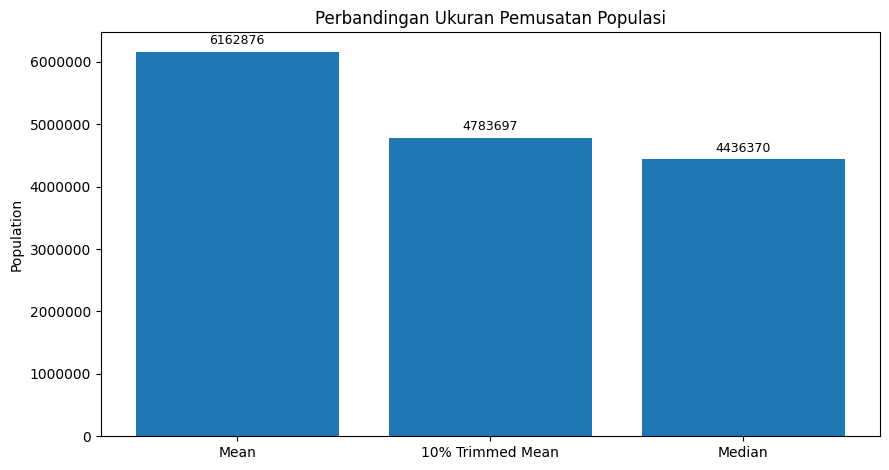

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(location_summary["Measure"], location_summary["Population"])
ax.set_title("Perbandingan Ukuran Pemusatan Populasi")
ax.set_xlabel("")
ax.set_ylabel("Population")
ax.ticklabel_format(style="plain", axis="y")
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Mean memiliki nilai tertinggi, median terendah, dan trimmed mean berada di antaranya. Pola tersebut konsisten dengan distribusi populasi yang memiliki beberapa observasi sangat besar.

## 5. Estimates of Variability

Ukuran pusat belum cukup untuk menggambarkan data. Variability mengukur seberapa tersebar observasi dari pusat distribusi.

Ukuran yang digunakan adalah standard deviation, range, interquartile range (IQR), dan median absolute deviation (MAD).

In [7]:
pop = state["Population"]
q1 = pop.quantile(0.25)
q3 = pop.quantile(0.75)

variability = pd.DataFrame({
    "Measure": [
        "Standard Deviation",
        "Range",
        "Interquartile Range (IQR)",
        "Median Absolute Deviation (MAD)"
    ],
    "Value": [
        pop.std(),
        pop.max() - pop.min(),
        q3 - q1,
        robust.scale.mad(pop)
    ]
})

display(variability)

,Measure,Value
0,Standard Deviation,"6,848,235.347"
1,Range,"36,690,330.000"
2,Interquartile Range (IQR),"4,847,308.000"
3,Median Absolute Deviation (MAD),"3,849,876.146"


**Interpretasi:** Standard deviation sensitif terhadap nilai ekstrem, sedangkan IQR dan MAD lebih robust. Karena distribusi populasi sangat tidak merata, penggunaan ukuran robust dapat memberikan perspektif tambahan.

### Visualisasi 2 — Boxplot Murder Rate

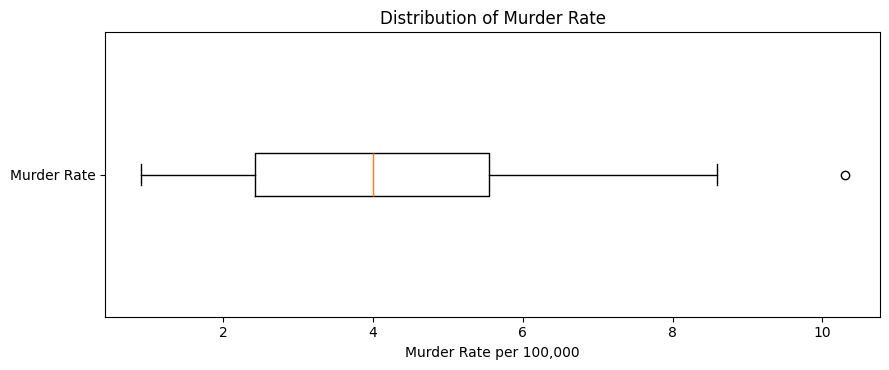

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.boxplot(state["Murder.Rate"], vert=False)
ax.set_title("Distribution of Murder Rate")
ax.set_xlabel("Murder Rate per 100,000")
ax.set_yticks([1])
ax.set_yticklabels(["Murder Rate"])
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Boxplot memperlihatkan median, IQR, whisker, dan kandidat observasi ekstrem pada murder rate. Observasi ekstrem perlu diperiksa berdasarkan konteks sebelum diputuskan untuk dihapus.

## 6. Exploring the Data Distribution

Distribusi data dapat dipelajari menggunakan percentile, boxplot, frequency table, histogram, dan density plot. Teknik-teknik ini memberikan sudut pandang yang berbeda terhadap konsentrasi dan bentuk data.

In [9]:
percentiles = [0.05, 0.25, 0.50, 0.75, 0.95]
percentile_table = state["Murder.Rate"].quantile(percentiles).to_frame("Murder Rate")
percentile_table.index = ["5%", "25%", "50%", "75%", "95%"]
display(percentile_table)

,Murder Rate
5%,1.600
25%,2.425
50%,4.000
75%,5.550
95%,6.510


**Interpretasi:** Median murder rate adalah 4.0. Rentang interquartile berada antara 2.425 dan 5.55, sehingga 50% observasi berada dalam rentang tersebut.

### Visualisasi 3 — Histogram dan Density Plot

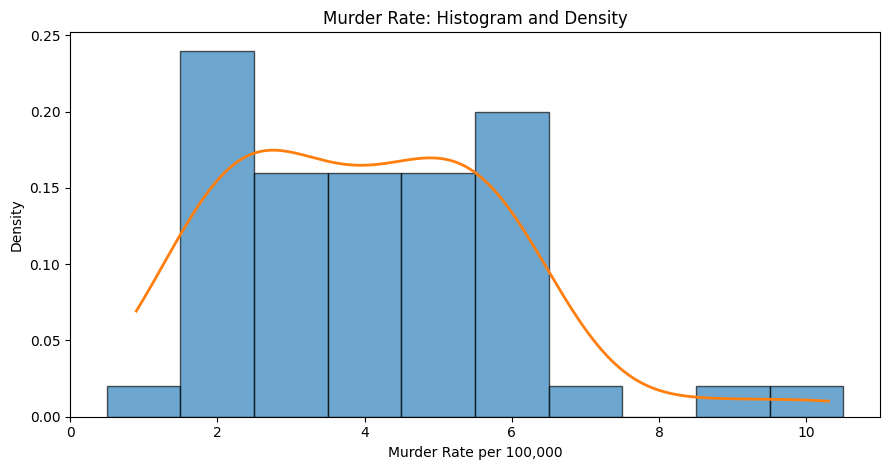

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.8))
values = state["Murder.Rate"].to_numpy()
bins = np.arange(0.5, 11.5, 1)
ax.hist(values, bins=bins, density=True, alpha=0.65, edgecolor="black")

grid = np.linspace(values.min(), values.max(), 300)
bandwidth = 1.06 * values.std(ddof=1) * len(values) ** (-1/5)
kde = np.exp(-0.5 * ((grid[:, None] - values[None, :]) / bandwidth) ** 2).sum(axis=1)
kde = kde / (len(values) * bandwidth * np.sqrt(2 * np.pi))
ax.plot(grid, kde, linewidth=2)

ax.set_title("Murder Rate: Histogram and Density")
ax.set_xlabel("Murder Rate per 100,000")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Histogram dan density menunjukkan konsentrasi murder rate terutama pada rentang rendah hingga menengah, dengan ekor menuju nilai yang lebih tinggi. Bentuk distribusi ini perlu diperhatikan ketika memilih statistik yang sensitif terhadap outlier.

### Visualisasi 4 — Empirical Cumulative Distribution Function (ECDF)

ECDF menunjukkan proporsi observasi yang berada di bawah atau sama dengan suatu nilai. Berbeda dari histogram, ECDF tidak memerlukan pemilihan bin.

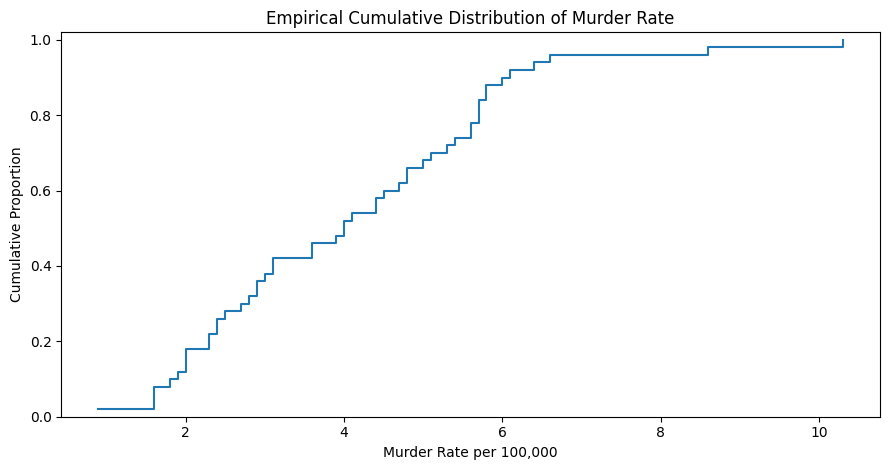

In [11]:
x = np.sort(state["Murder.Rate"].to_numpy())
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.step(x, y, where="post")
ax.set_title("Empirical Cumulative Distribution of Murder Rate")
ax.set_xlabel("Murder Rate per 100,000")
ax.set_ylabel("Cumulative Proportion")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** ECDF memudahkan pembacaan proporsi observasi pada threshold tertentu. Chart ini dapat digunakan untuk menjawab pertanyaan seperti berapa bagian negara bagian yang memiliki murder rate di bawah nilai tertentu.

## 7. Exploring Binary and Categorical Data

Data kategorikal terdiri dari label atau kelompok. Untuk data kategorikal, frekuensi dan proporsi sering lebih informatif daripada mean.

Sebagai contoh reproduksi bagian categorical data, digunakan agregasi penyebab keterlambatan penerbangan DFW yang tersedia dalam dataset pendukung Chapter 1.

In [12]:
dfw["Share (%)"] = 100 * dfw["Delay_Minutes"] / dfw["Delay_Minutes"].sum()
display(dfw.sort_values("Delay_Minutes", ascending=False))

,Cause,Delay_Minutes,Share (%)
4,Inbound,"118,427.820",42.428
1,ATC,"84,856.500",30.401
0,Carrier,"64,263.160",23.023
2,Weather,"11,235.420",4.025
3,Security,343.150,0.123


**Interpretasi:** Kolom `Share (%)` menunjukkan kontribusi relatif setiap penyebab terhadap total delay yang tercatat pada dataset. Ini membantu membandingkan kategori dengan skala yang berbeda.

### Visualisasi 5 — Komposisi Penyebab Delay

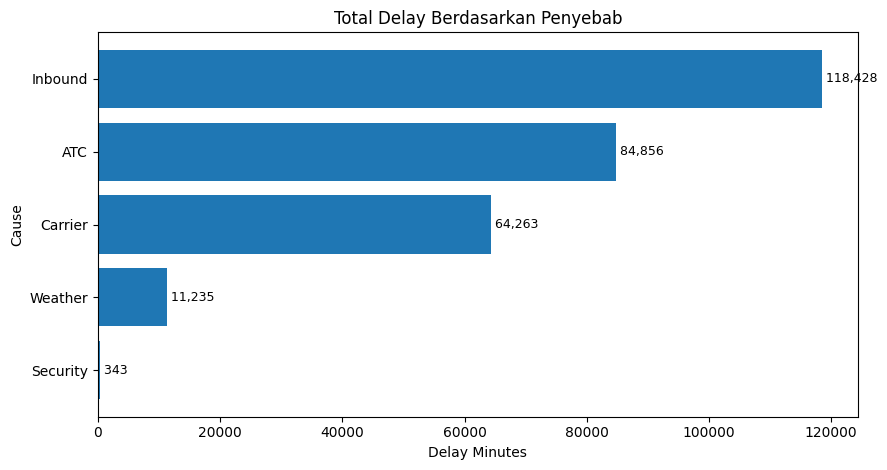

In [13]:
plot_dfw = dfw.sort_values("Delay_Minutes", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(plot_dfw["Cause"], plot_dfw["Delay_Minutes"])

ax.set_title("Total Delay Berdasarkan Penyebab")
ax.set_xlabel("Delay Minutes")
ax.set_ylabel("Cause")

for bar, value in zip(bars, plot_dfw["Delay_Minutes"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Pada data agregat ini, Inbound memiliki total delay terbesar, diikuti ATC dan Carrier. Weather dan Security memiliki kontribusi jauh lebih kecil. Hasil ini hanya menggambarkan dataset yang digunakan, bukan generalisasi untuk seluruh bandara atau periode.

## 8. Correlation

Correlation mengukur kekuatan dan arah hubungan linear. Pearson correlation berada pada rentang −1 hingga +1.

Nilai korelasi tidak boleh langsung diartikan sebagai hubungan sebab-akibat. Korelasi hanya menunjukkan asosiasi linear pada data yang dianalisis.

In [14]:
corr = state[["Population", "Murder.Rate"]].corr()
display(corr)

,Population,Murder.Rate
Population,1.000,0.182
Murder.Rate,0.182,1.000


### Visualisasi 6 — Correlation Heatmap

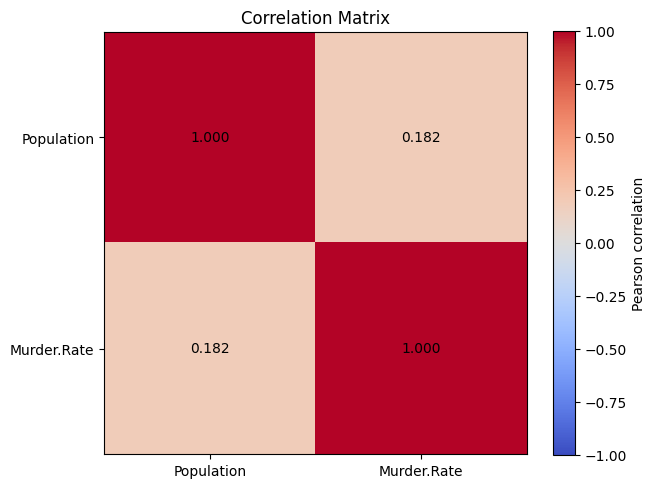

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Heatmap merangkum hubungan linear antara Population dan Murder.Rate. Nilai korelasi perlu dipahami bersama scatterplot karena koefisien korelasi saja tidak menunjukkan bentuk hubungan secara lengkap.

## 9. Exploring Two or More Variables

EDA multivariat digunakan untuk menemukan pola yang tidak terlihat ketika variabel dianalisis secara terpisah. Scatterplot merupakan alat utama untuk hubungan numeric-versus-numeric.

Population memiliki rentang yang sangat besar, sehingga sumbu-x menggunakan skala logaritmik agar negara bagian kecil dan besar tetap terlihat.

### Visualisasi 7 — Population vs Murder Rate

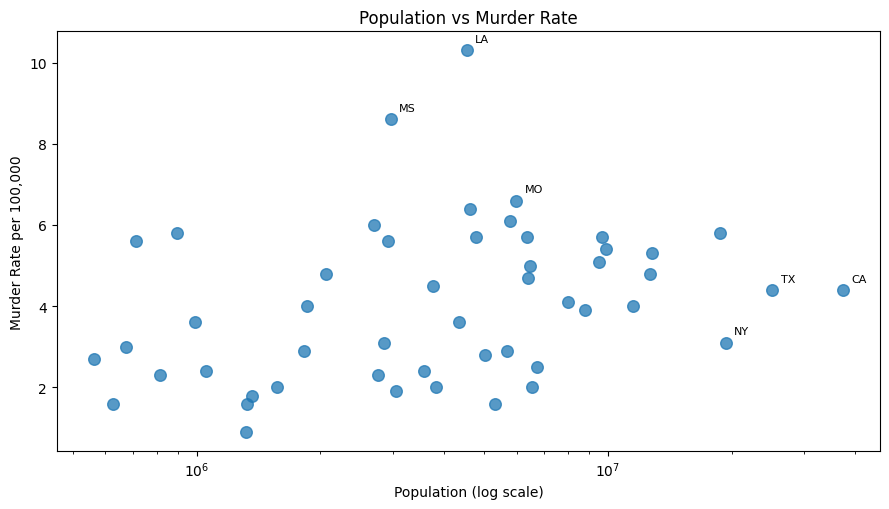

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.2))

ax.scatter(
    state["Population"],
    state["Murder.Rate"],
    s=70,
    alpha=0.75
)

ax.set_xscale("log")
ax.set_title("Population vs Murder Rate")
ax.set_xlabel("Population (log scale)")
ax.set_ylabel("Murder Rate per 100,000")

label_rows = pd.concat([
    state.nlargest(3, "Murder.Rate"),
    state.nlargest(3, "Population")
]).drop_duplicates()

for _, row in label_rows.iterrows():
    ax.annotate(
        row["Abbreviation"],
        (row["Population"], row["Murder.Rate"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Scatterplot menunjukkan bahwa hubungan Population dan Murder.Rate tidak dapat disederhanakan menjadi hubungan linear yang kuat. Beberapa negara bagian dengan populasi relatif kecil memiliki murder rate tinggi, sehingga perlu melihat distribusi dan konteks sebelum menarik kesimpulan.

### Visualisasi 8 — Hexbin Population vs Murder Rate

Hexbin mengelompokkan titik ke dalam area heksagonal berdasarkan kepadatan. Teknik ini sangat berguna pada dataset besar ketika scatterplot mengalami overplotting.

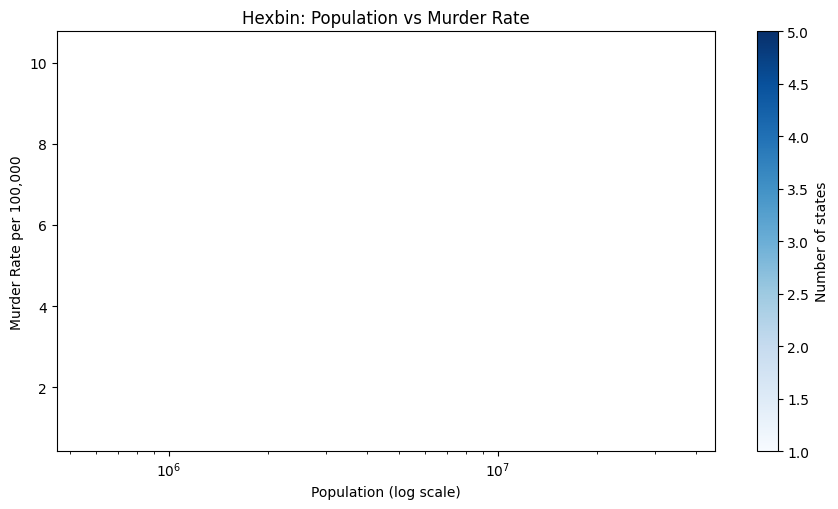

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.2))

hb = ax.hexbin(
    state["Population"],
    state["Murder.Rate"],
    gridsize=12,
    mincnt=1,
    cmap="Blues"
)

ax.set_xscale("log")
ax.set_title("Hexbin: Population vs Murder Rate")
ax.set_xlabel("Population (log scale)")
ax.set_ylabel("Murder Rate per 100,000")

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of states")

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Intensitas warna merepresentasikan jumlah observasi pada area tertentu. Karena dataset hanya memiliki 50 observasi, scatterplot tetap lebih informatif untuk melihat setiap negara bagian secara individual, sedangkan hexbin lebih relevan sebagai teknik visualisasi data besar.

## 10. Analisis Multivariabel: Population Group vs Murder Rate

Untuk melihat perbedaan distribusi murder rate pada tingkat populasi yang berbeda, Population dibagi menjadi tiga kelompok berdasarkan quantile. Pembagian ini hanya digunakan sebagai alat eksploratif.

In [18]:
state["Population_Group"] = pd.qcut(
    state["Population"],
    q=3,
    labels=["Low Population", "Medium Population", "High Population"]
)

group_summary = (
    state.groupby("Population_Group", observed=False)["Murder.Rate"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(group_summary)

,Population_Group,count,mean,median,std
0,Low Population,17,3.135,2.700,1.583
1,Medium Population,16,4.631,4.050,2.549
2,High Population,17,4.465,4.700,1.111


### Visualisasi 9 — Murder Rate per Population Group

/tmp/ipykernel_668/3968974870.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


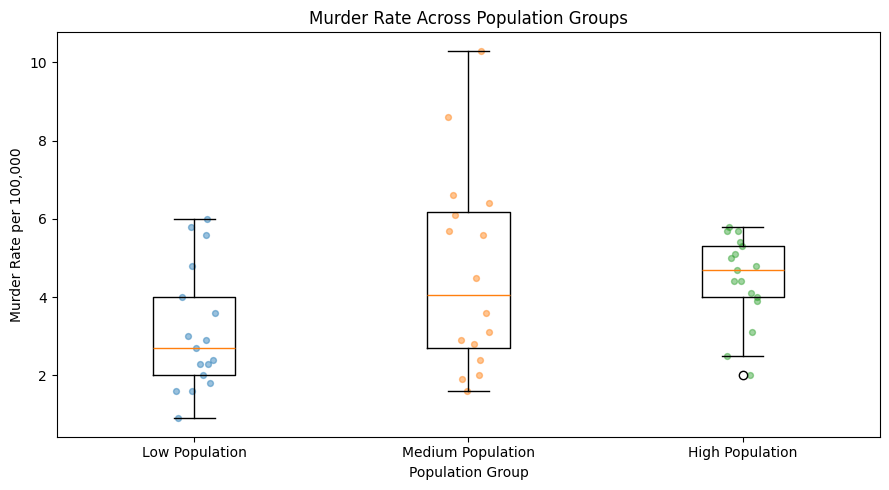

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

groups = ["Low Population", "Medium Population", "High Population"]
data = [
    state.loc[state["Population_Group"] == g, "Murder.Rate"].to_numpy()
    for g in groups
]

ax.boxplot(data, labels=groups)

rng = np.random.default_rng(42)
for i, vals in enumerate(data, start=1):
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(i + jitter, vals, s=18, alpha=0.45)

ax.set_title("Murder Rate Across Population Groups")
ax.set_xlabel("Population Group")
ax.set_ylabel("Murder Rate per 100,000")

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Boxplot membandingkan median, IQR, dan penyebaran murder rate pada tiga kelompok populasi. Perbedaan visual antar kelompok dapat digunakan sebagai titik awal analisis lanjutan, tetapi tidak cukup untuk menyimpulkan hubungan sebab-akibat.

## 11. Pemeriksaan Outlier

Outlier adalah observasi yang berbeda cukup jauh dari mayoritas data. Dalam EDA, outlier sebaiknya diidentifikasi dan dipahami terlebih dahulu, bukan langsung dihapus.

Metode IQR menggunakan:

**Lower fence = Q1 − 1.5 × IQR**

**Upper fence = Q3 + 1.5 × IQR**

In [20]:
murder = state["Murder.Rate"]

q1 = murder.quantile(0.25)
q3 = murder.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = state[
    (murder < lower_fence) | (murder > upper_fence)
][["State", "Murder.Rate"]].sort_values("Murder.Rate")

print(f"Q1 = {q1:.3f}")
print(f"Q3 = {q3:.3f}")
print(f"IQR = {iqr:.3f}")
print(f"Lower fence = {lower_fence:.3f}")
print(f"Upper fence = {upper_fence:.3f}")

display(outliers)

Q1 = 2.425
Q3 = 5.550
IQR = 3.125
Lower fence = -2.263
Upper fence = 10.238


,State,Murder.Rate
17,Louisiana,10.300


**Interpretasi:** Observasi yang melewati fence merupakan kandidat outlier secara statistik. Status sebagai outlier tidak otomatis berarti data salah; konteks dan validitas observasi tetap harus diperiksa.

## 12. Relevansi EDA terhadap Machine Learning dan Deep Learning

Chapter 1 berfokus pada EDA, bukan pembangunan neural network. Namun, EDA merupakan tahap penting sebelum model Machine Learning maupun Deep Learning.

Beberapa hubungan praktisnya:

1. Distribusi fitur membantu menentukan kebutuhan transformasi atau scaling.
2. Outlier dapat memengaruhi proses training model tertentu.
3. Correlation membantu memahami hubungan dan potensi redundansi fitur.
4. Variabel kategorikal perlu dipersiapkan melalui encoding.
5. Missing values harus ditangani sebelum data masuk ke pipeline.
6. Data leakage harus dicegah saat preprocessing train dan test.

### Catatan tentang Deep Learning

Karena materi Chapter 1 memang berisi EDA, memaksakan neural network pada dataset 50 negara bagian tidak tepat secara metodologis. Notebook ini menempatkan Deep Learning pada konteks yang benar: **EDA sebagai tahap persiapan dan diagnosis sebelum training model**, bukan mengganti materi statistik Chapter 1 dengan model neural network.

## 13. Ringkasan Chapter

| Konsep | Implementasi |
|---|---|
| Structured / rectangular data | Dimensi, tipe data, missing value |
| Estimates of location | Mean, trimmed mean, median, weighted statistics |
| Estimates of variability | Standard deviation, range, IQR, MAD |
| Data distribution | Percentile, histogram, density, ECDF |
| Categorical data | Frequency dan proporsi |
| Correlation | Correlation matrix dan heatmap |
| Numeric vs numeric | Scatterplot dan hexbin |
| Multivariable exploration | Grouping dan grouped boxplot |
| Outlier analysis | IQR fences |
| ML/DL preparation | Interpretasi EDA sebagai tahap preprocessing |

**Kesimpulan:** EDA membantu menjawab pertanyaan dasar sebelum pemodelan: data seperti apa yang tersedia, bagaimana distribusinya, seberapa besar variasinya, apakah terdapat observasi ekstrem, dan bagaimana variabel saling berhubungan.

## 14. Referensi

1. Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python* (2nd ed.). O'Reilly Media.
2. Gedeck, P. et al. Code repository for *Practical Statistics for Data Scientists*.
3. Dataset `state.csv` dan `dfw_airline.csv` dari repository kode buku digunakan sebagai dasar implementasi Chapter 1.

**Catatan akademik:** Kode notebook ini ditulis ulang dan diperluas dengan visualisasi serta interpretasi tambahan, sementara struktur konsep mengikuti Chapter 1.